In [2]:
import sys
print(sys.executable)

C:\Users\caseh\Documents\bayesian-mmm-retail\.venv\Scripts\python.exe


In [1]:
import pymc_marketing
import pymc as pm
import arviz as az

print("pymc-marketing:", pymc_marketing.__version__)
print("pymc:", pm.__version__)
print("arviz:", az.__version__)

g++ not available, if using conda: `conda install gxx`


pymc-marketing: 1.0.0
pymc: 6.0.1
arviz: 1.3.0


In [3]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n_weeks = 130
dates = pd.date_range("2023-01-02", periods=n_weeks, freq="W-MON")

trend = np.linspace(0, 20, n_weeks)
yearly_seasonality = 10 * np.sin(2 * np.pi * np.arange(n_weeks) / 52)
promo = rng.binomial(1, 0.15, n_weeks)

tv_spend = np.clip(50 + 20 * np.sin(2 * np.pi * np.arange(n_weeks) / 52 + 1) + rng.normal(0, 5, n_weeks), 0, None)
google_search_spend = np.clip(30 + rng.normal(0, 8, n_weeks), 0, None)
tiktok_spend = np.clip(15 + 0.1 * np.arange(n_weeks) + rng.normal(0, 4, n_weeks), 0, None)

print("Weeks:", n_weeks)
print("TV spend range:", tv_spend.min().round(2), "-", tv_spend.max().round(2))

Weeks: 130
TV spend range: 23.38 - 79.09


In [4]:
def geometric_adstock(x, alpha, l_max=8):
    weights = alpha ** np.arange(l_max)
    padded = np.concatenate([np.zeros(l_max - 1), x])
    return np.array([
        np.dot(padded[i:i + l_max][::-1], weights) / weights.sum()
        for i in range(len(x))
    ])

def logistic_saturation(x, lam):
    return (1 - np.exp(-lam * x)) / (1 + np.exp(-lam * x))

true_params = {
    "tv":     {"alpha": 0.6, "lam": 0.05, "beta": 1200},
    "search": {"alpha": 0.4, "lam": 0.08, "beta": 900},
    "tiktok": {"alpha": 0.3, "lam": 0.03, "beta": 700},
}

tv_effect = true_params["tv"]["beta"] * logistic_saturation(
    geometric_adstock(tv_spend, true_params["tv"]["alpha"]), true_params["tv"]["lam"])
search_effect = true_params["search"]["beta"] * logistic_saturation(
    geometric_adstock(google_search_spend, true_params["search"]["alpha"]), true_params["search"]["lam"])
tiktok_effect = true_params["tiktok"]["beta"] * logistic_saturation(
    geometric_adstock(tiktok_spend, true_params["tiktok"]["alpha"]), true_params["tiktok"]["lam"])

baseline = 2000
sales = (
    baseline + trend * 10 + yearly_seasonality * 20
    + 300 * promo + tv_effect + search_effect + tiktok_effect
    + rng.normal(0, 100, n_weeks)
)

df = pd.DataFrame({
    "date_week": dates,
    "tv_spend": tv_spend,
    "google_search_spend": google_search_spend,
    "tiktok_spend": tiktok_spend,
    "promo": promo,
    "trend": trend,
    "yearly_seasonality": yearly_seasonality,
    "sales": sales,
})
df.to_csv("../data/scenario_a/scenario_a_train.csv", index=False)
print(df.shape)
df["sales"].describe()

(130, 8)


count     130.000000
mean     4093.543660
std       318.496520
min      3431.694350
25%      3813.585554
50%      4153.546159
75%      4332.513729
max      4822.217968
Name: sales, dtype: float64

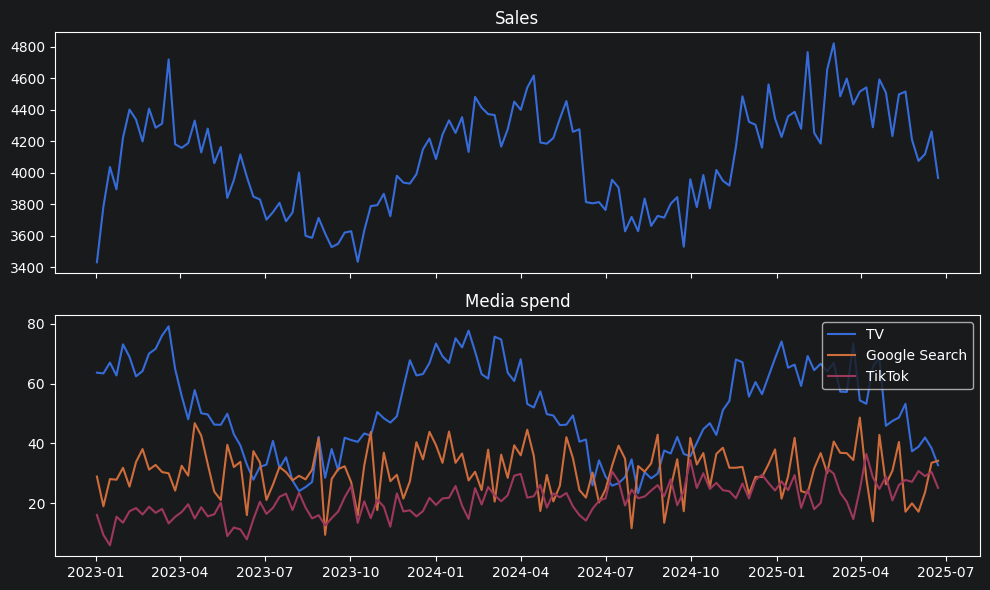

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(df["date_week"], df["sales"])
axes[0].set_title("Sales")
axes[1].plot(df["date_week"], df["tv_spend"], label="TV")
axes[1].plot(df["date_week"], df["google_search_spend"], label="Google Search")
axes[1].plot(df["date_week"], df["tiktok_spend"], label="TikTok")
axes[1].legend()
axes[1].set_title("Media spend")
plt.tight_layout()
plt.savefig("../figures/scenario_a/day1_spend_and_sales.png")
plt.show()